# Set Working Directory

Only run this once to make sure that the working directory is in the same folder `main.py` is located.

In [ ]:
import os
from pathlib import Path

os.chdir(Path.cwd().parent)
print(f"cwd: {os.getcwd()}")

cwd: c:\Users\u0144109\Documents\Python Scripts\fcs-control


# Get Device Manager

In [ ]:
import logging

from src.fcs_control.devices import get_device_manager

logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    force=True, # important in Jupyter
    )
logging.getLogger("pyvisa").setLevel(logging.CRITICAL)
logging.getLogger("matplotlib").setLevel(logging.CRITICAL)
dm = get_device_manager()

print(dm.devices)

2026-09-19 15:46:45,752 - src.fcs_control.devices._device_manager - WARNING - quantum not connected: No ports named ASRL9 found.
2026-09-19 15:46:45,794 - src.fcs_control.devices._device_manager - WARNING - primaryscope not connected: No ports named USB0 found.
2026-09-19 15:46:45,797 - src.fcs_control.devices._device_manager - WARNING - secondaryscope not connected: No ports named USB0 found.
2026-09-19 15:46:45,798 - src.fcs_control.devices._device_manager - INFO - opoopa successfully connected


{'quantum': {'class': <class 'src.fcs_control.devices._quantum.Quantum'>, 'kwargs': {}, 'description': 'Quantum 9520 Delay Generator', 'occupied': False, 'instance': None}, 'primaryscope': {'class': <class 'src.fcs_control.devices._scope.Scope'>, 'kwargs': {'prisec': 'primary'}, 'description': 'Primary MDO34 Scope', 'occupied': False, 'instance': None}, 'secondaryscope': {'class': <class 'src.fcs_control.devices._scope.Scope'>, 'kwargs': {'prisec': 'secondary'}, 'description': 'Secondary MDO34 Scope', 'occupied': False, 'instance': None}, 'opoopa': {'class': <class 'src.fcs_control.devices._opoopa.Opoopa'>, 'kwargs': {}, 'description': 'OPO/OPA System', 'occupied': False, 'instance': <src.fcs_control.devices._opoopa.Opoopa object at 0x0000029E55CB6660>}}


## Refresh

Connect all in case that the device manager was initialised, but devices need to be reconnected.

In [11]:
dm.connect_all()

2026-09-16 17:31:24,233 - src.fcs_control.devices._quantum - INFO - Connected to Quantum 9520 at port ASRL9::INSTR
2026-09-16 17:31:24,334 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE1:DELAY?
2026-09-16 17:31:24,336 - src.fcs_control.devices._quantum - DEBUG - READ 'ok\r\n'
2026-09-16 17:31:24,340 - src.fcs_control.devices._quantum - DEBUG - READ '0.00000000000\r\n'
2026-09-16 17:31:24,444 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE1:CMOD?
2026-09-16 17:31:24,449 - src.fcs_control.devices._quantum - DEBUG - READ 'NORM\r\n'
2026-09-16 17:31:24,555 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE1:SYNC?
2026-09-16 17:31:24,559 - src.fcs_control.devices._quantum - DEBUG - READ 'T0\r\n'
2026-09-16 17:31:24,660 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE1:WIDTH?
2026-09-16 17:31:24,665 - src.fcs_control.devices._quantum - DEBUG - READ '0.00000100000\r\n'
2026-09-16 17:31:24,765 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE2:DELAY?
202

# Quantum, delay generator

In [4]:
info = dm.devices['quantum']
quantum = info['instance']

In [4]:
print(quantum.settings)

{'A': {'delay': 0.0, 'mode': 'NORM\r\n', 'reference': 'T0', 'width': 1.0}, 'B': {'delay': -595.0, 'mode': 'NORM\r\n', 'reference': 'C', 'width': 2.0}, 'C': {'delay': 970.0, 'mode': 'NORM\r\n', 'reference': 'A', 'width': 1.0}, 'D': {'delay': 420.0, 'mode': 'NORM\r\n', 'reference': 'C', 'width': 1000.0}, 'E': {'delay': 0.0, 'mode': 'DCYC\r\n', 'reference': 'D', 'width': 200.0}, 'F': {'delay': 0.0, 'mode': 'DCYC\r\n', 'reference': 'E', 'width': 2500.002}, 'G': {'delay': -790.0, 'mode': 'NORM\r\n', 'reference': 'H', 'width': 15.0}, 'H': {'delay': 0.0, 'mode': 'DCYC\r\n', 'reference': 'D', 'width': 15.0}}


## Is alive

In [8]:
quantum.is_alive()

2026-09-16 17:13:53,407 - src.fcs_control.devices._quantum - DEBUG - SEND *IDN?
2026-09-16 17:13:55,425 - src.fcs_control.devices._quantum - WARNING - Quantum on port ASRL9::INSTR appears disconnected: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.


False

## get_all

In [6]:
CH = 'A' 

print(quantum.get_all(CH))

2026-09-16 17:13:42,759 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE1:DELAY?
2026-09-16 17:13:42,764 - src.fcs_control.devices._quantum - DEBUG - READ '0.00000000000\r\n'
2026-09-16 17:13:42,866 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE1:CMOD?
2026-09-16 17:13:42,870 - src.fcs_control.devices._quantum - DEBUG - READ 'NORM\r\n'
2026-09-16 17:13:42,972 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE1:SYNC?
2026-09-16 17:13:42,976 - src.fcs_control.devices._quantum - DEBUG - READ 'T0\r\n'
2026-09-16 17:13:43,077 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE1:WIDTH?
2026-09-16 17:13:43,082 - src.fcs_control.devices._quantum - DEBUG - READ '0.00000100000\r\n'


{'delay': 0.0, 'mode': 'NORM\r\n', 'reference': 'T0', 'width': 1.0}


## Delay

In [7]:
SET = 0
CH = 'A'

quantum.set_delay(CH, SET)
quantum.get_delay(CH)

2026-09-16 17:13:45,521 - src.fcs_control.devices._quantum - DEBUG - SEND *OPC?
2026-09-16 17:13:45,522 - src.fcs_control.devices._quantum - DEBUG - READ 'ok\r\n'
2026-09-16 17:13:45,524 - src.fcs_control.devices._quantum - DEBUG - READ '?3\r\n'
2026-09-16 17:13:45,524 - src.fcs_control.devices._quantum - DEBUG - OPC? '?3\r\n'
2026-09-16 17:13:45,525 - src.fcs_control.devices._quantum - INFO - Delay of CHA on Quantum (ASRL9::INSTR) is set to 0.00 µs
2026-09-16 17:13:45,627 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE1:DELAY?
2026-09-16 17:13:45,631 - src.fcs_control.devices._quantum - DEBUG - READ '0.00000000000\r\n'


0.0

## Mode

In [12]:
CH = 'A' 

quantum.set_mode(CH, 'NORM')
quantum.get_mode(CH)

2026-09-16 17:18:06,035 - src.fcs_control.devices._quantum - DEBUG - SEND *OPC?
2026-09-16 17:18:06,037 - src.fcs_control.devices._quantum - DEBUG - READ 'ok\r\n'
2026-09-16 17:18:06,038 - src.fcs_control.devices._quantum - DEBUG - READ '?3\r\n'
2026-09-16 17:18:06,039 - src.fcs_control.devices._quantum - DEBUG - OPC? '?3\r\n'
2026-09-16 17:18:06,040 - src.fcs_control.devices._quantum - INFO - CHA on Quantum (ASRL9::INSTR) has been set to mode NORM
2026-09-16 17:18:06,141 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE1:CMOD?
2026-09-16 17:18:06,145 - src.fcs_control.devices._quantum - DEBUG - READ 'NORM\r\n'


'NORM\r\n'

## Reference

In [17]:
CH = 'A'
REF = 'T0'

quantum.set_reference(CH, REF)
quantum.get_reference(CH)

2026-09-16 17:21:10,147 - src.fcs_control.devices._quantum - DEBUG - SEND *OPC?
2026-09-16 17:21:10,150 - src.fcs_control.devices._quantum - DEBUG - READ '?5?3\r\n'
2026-09-16 17:21:10,151 - src.fcs_control.devices._quantum - DEBUG - OPC? '?5?3\r\n'
2026-09-16 17:21:10,151 - src.fcs_control.devices._quantum - INFO - Reference of CHA on Quantum (ASRL9::INSTR) is set to TO
2026-09-16 17:21:10,258 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE1:SYNC?
2026-09-16 17:21:10,262 - src.fcs_control.devices._quantum - DEBUG - READ 'T0\r\n'


'T0'

## Width

In [20]:
CH = 'A'
WIDTH = 1

quantum.set_width(CH, WIDTH)
quantum.get_width(CH)

2026-09-16 17:22:11,972 - src.fcs_control.devices._quantum - DEBUG - SEND *OPC?
2026-09-16 17:22:11,973 - src.fcs_control.devices._quantum - DEBUG - READ 'ok\r\n'
2026-09-16 17:22:11,975 - src.fcs_control.devices._quantum - DEBUG - READ '?3\r\n'
2026-09-16 17:22:11,976 - src.fcs_control.devices._quantum - DEBUG - OPC? '?3\r\n'
2026-09-16 17:22:11,977 - src.fcs_control.devices._quantum - INFO - Width of CHA on Quantum (ASRL9::INSTR) is set to 1.00 µs
2026-09-16 17:22:12,078 - src.fcs_control.devices._quantum - DEBUG - SEND :PULSE1:WIDTH?
2026-09-16 17:22:12,084 - src.fcs_control.devices._quantum - DEBUG - READ '0.00000100000\r\n'


1.0

## On/Off

In [7]:
CH = 'A' 

quantum.onoff(CH, 'on')

2026-09-16 17:25:27,766 - src.fcs_control.devices._quantum - DEBUG - SEND *OPC?
2026-09-16 17:25:27,768 - src.fcs_control.devices._quantum - DEBUG - READ 'ok\r\n'
2026-09-16 17:25:27,770 - src.fcs_control.devices._quantum - DEBUG - READ '?3\r\n'
2026-09-16 17:25:27,771 - src.fcs_control.devices._quantum - DEBUG - OPC? '?3\r\n'
2026-09-16 17:25:27,772 - src.fcs_control.devices._quantum - INFO - CHA on Quantum (ASRL9::INSTR) has been switched on


## t0_normal

In [8]:
quantum.t0_normal()

2026-09-16 17:26:24,947 - src.fcs_control.devices._quantum - DEBUG - SEND *OPC?
2026-09-16 17:26:24,948 - src.fcs_control.devices._quantum - DEBUG - READ 'ok\r\n'
2026-09-16 17:26:24,950 - src.fcs_control.devices._quantum - DEBUG - READ '?3\r\n'
2026-09-16 17:26:24,950 - src.fcs_control.devices._quantum - DEBUG - OPC? '?3\r\n'


## Run/Stop

In [10]:
RUNSTOP = 'stop' 

quantum.runstop(RUNSTOP)

2026-09-16 17:27:03,427 - src.fcs_control.devices._quantum - DEBUG - SEND *OPC?
2026-09-16 17:27:03,429 - src.fcs_control.devices._quantum - DEBUG - READ 'ok\r\n'
2026-09-16 17:27:03,430 - src.fcs_control.devices._quantum - DEBUG - READ '?3\r\n'
2026-09-16 17:27:03,431 - src.fcs_control.devices._quantum - DEBUG - OPC? '?3\r\n'


# Oscilloscopes

In [12]:
info = dm.devices['secondaryscope']
scope = info['instance']

## is_alive

In [13]:
scope.is_alive()

2026-09-16 17:31:41,390 - src.fcs_control.devices._scope - DEBUG - ID TEKTRONIX,MDO34,C015331,CF:91.1CT FV:v1.8.31



True

## Read

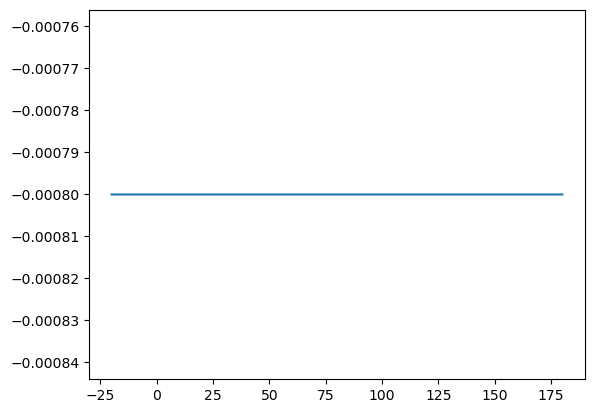

In [25]:
CH = 'CH1'

import matplotlib.pyplot as plt

data = scope.read(CH)
plt.plot(data[:, 0]*1e6, data[:, 1])
plt.show()

## Run/Stop

In [18]:
scope.runstop('run')

## Horizontal Resolution

In [32]:
MICPDIV = 20

scope.set_micpdiv(MICPDIV)
scope.get_micpdiv()

20.0

## Sample Mode

In [33]:
scope.set_samplemode()

## Average

In [36]:
AVG = 32

scope.set_numavg(AVG)

# OPO/OPA

In [3]:
info = dm.devices['opoopa']
opoopa = info['instance']

## Read Wavelength

In [4]:
opoopa.read_wavelength()

FileNotFoundError: [WinError 2] The system cannot find the file specified